<a href="https://colab.research.google.com/github/Prisze/AAI-501/blob/priscilla-dev/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [34]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import numpy as np
from matplotlib import pyplot as plt


In [2]:
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Dataset

I got the dataset from `sklearn` as it was easier to import, and also provided help with the cleanup. The original dataset includes much metadata, such as signatures, quotes and headers, that may be easier for the model to overfit on when predicting a class. Because of this, I used the sklear dataset with all of them stripped.

In [3]:
dataset = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

In [4]:
df = pd.DataFrame({
    'text': dataset['data'],
    'group': [dataset['target_names'][target] for target in dataset['target']],
    'group_id': dataset['target']
})

## Cleanup

I used `nltk`'s English tokenizer to divide the text into tokens, removed those that contained non-alphabetic characters and those that appeared in the `stopwords` dictionary, and lastly set them all as lowercase.

In [5]:
def preprocess(text):
    tokens = word_tokenize(text)
    return ' '.join([token.lower() for token in tokens if token.isalpha() and token.lower() not in stopwords])


df['clean_text'] = df['text'].apply(preprocess)

## Embeddings

To generate the embeddings I used a pre-trained BERT model from the library `transformers` by the HuggingFace community. The version of the model I used can only process 512 word embeddings at once, so I truncate the dataset and I only work with the first 512 embeddings per element.

In [11]:
import torch
from transformers import BertTokenizer, BertModel

bert_tokenize = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to('cuda' if torch.cuda.is_available() else 'cpu')

def get_embedding(text):
    bert_tokens = bert_tokenize(text)[:512]
    with torch.no_grad():
        outputs = bert_model(
            input_ids=torch.tensor(bert_tokens['input_ids']).unsqueeze(0).cuda(),
            attention_mask=torch.tensor(bert_tokens['attention_mask']).unsqueeze(0).cuda(),
            token_type_ids=torch.tensor(bert_tokens['token_type_ids']).unsqueeze(0).cuda(),
        )

    cls_embedding = outputs.last_hidden_state[:, 0, :]
    return cls_embedding.cpu().squeeze().numpy()


df['embedding'] = df['clean_text'].apply(get_embedding)

Token indices sequence length is longer than the specified maximum sequence length for this model (704 > 512). Running this sequence through the model will result in indexing errors


# Train

## 20 Classes

First I used the whole `group` labels as targets for my predictor. This means I will have `20` classes to predict from. I will be using an `SVC` classifier to predict what discussion group each post should belong to.

In [75]:
# Split into test and training sets
X_train, X_test, y_train, y_test = train_test_split(df['embedding'], df['group'])

In [76]:
# Train the classifier
classifier = SVC()
classifier.fit(np.vstack(X_train.values), y_train.values)

SVC()

In [77]:
# Predict on test data
prediction = classifier.predict(np.vstack(X_test.values))

Accuracy Score: 0.59
Precision Score (weighted): 0.60
F1 Score (weighted): 0.59


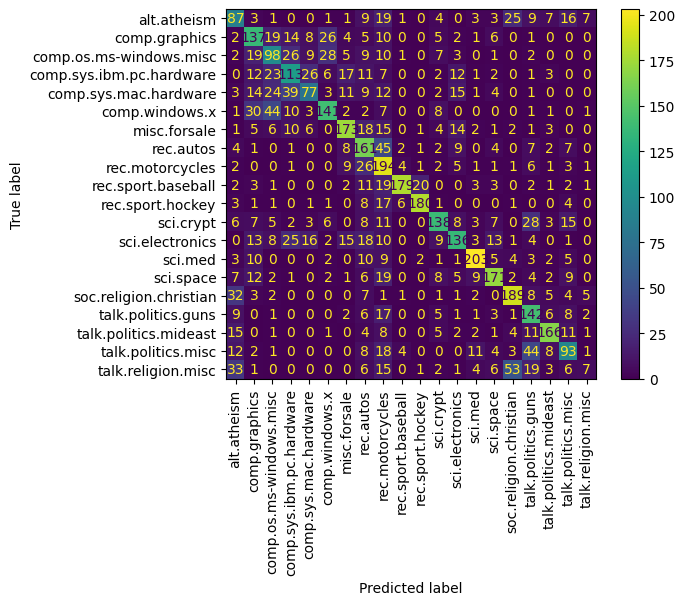

In [88]:
print(f'Accuracy Score: {accuracy_score(y_test.values, prediction):.2f}')
print(f'Precision Score (weighted): {precision_score(y_test.values, prediction, average="weighted"):.2f}')
print(f'F1 Score (weighted): {f1_score(y_test.values, prediction, average="weighted"):.2f}')


ConfusionMatrixDisplay(confusion_matrix(y_test.values, prediction), display_labels=classifier.classes_).plot(); plt.xticks(rotation=90); plt.show()

We see that the prediction accuracy is `59%`, which is much higher than random chance (50%). In the confusion matrix, we can see that the most misclassified group is `talk.religion.misc`, which gets classified as `soc.religion.cristion`, which is reasonable as they would have much in common. The second most misclassified group is `rec.autos` as `rec.motorcycles`, which again would make sense.

## 5 classes

In this section I will only use the first part of each group's name (what goes before the first dot) as prediction targets. This means that the model will only be predicting to `5` classes.

In [89]:
# Extract root from group name
df['root_group'] = df['group'].apply(lambda x: x.split('.')[0])

In [90]:
# Split and train
X_train, X_test, y_train, y_test = train_test_split(df['embedding'], df['root_group'])

classifier_root = SVC()
classifier_root.fit(np.vstack(X_train.values), y_train.values)

SVC()

In [91]:
# Predict
prediction = classifier_root.predict(np.vstack(X_test.values))

Accuracy Score: 0.75
Precision Score (weighted): 0.75
F1 Score (weighted): 0.74


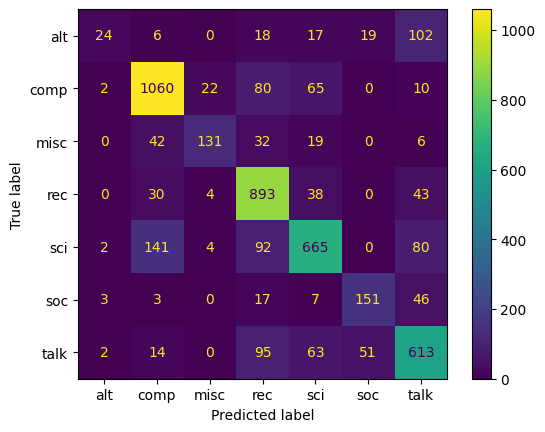

In [92]:
# Display metrics
print(f'Accuracy Score: {accuracy_score(y_test.values, prediction):.2f}')
print(f'Precision Score (weighted): {precision_score(y_test.values, prediction, average="weighted"):.2f}')
print(f'F1 Score (weighted): {f1_score(y_test.values, prediction, average="weighted"):.2f}')

ConfusionMatrixDisplay(confusion_matrix(y_test.values, prediction), display_labels=classifier_root.classes_).plot(); plt.show()

We can see that by only predicting 5 classes the model can achieve a `75%` accuracy when predicting the category of the texts. In this case the most misclassified group is `sci` (science) as `comp` (computers), which again would make sense as it is expected they would have some things in common.